# Week 2 — Task 5: Capstone — redesign one chart for the human visual system

**Data:** `data/gapminder.csv` — 142 countries × 12 years, life expectancy.

Step 5 asks a real person, who has not seen the data, to describe the **redesigned** chart in one
sentence — a judgment with no timing involved, collected the same way as Tasks 2 and 4.

> Run `python3 download_assignment_data.py` first, and run this notebook from the `assignments/` folder.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette ---------------------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"

# Context grey + ink. Week 2's rule: "grey is a colour choice" - context
# goes grey, the message gets ONE strong colour.
GREY = "#bbbbbb"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name, dpi=150):
    # Regular charts: 150 dpi is plenty and keeps notebooks small.
    # Task 5's final export is re-saved separately at the required 300 dpi.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE, dpi=dpi, bbox_inches="tight")


def footnote(ax, text, y=-0.2):
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Load the data

In [2]:
g = pd.read_csv(DATA / "gapminder.csv")
print("Rows:", g.shape[0], " Countries:", g["country"].nunique(), " Missing:", int(g.isna().sum().sum()))
g.head(3)

Rows: 1704  Countries: 142  Missing: 0


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710


Balanced, nothing missing — **no rows excluded** anywhere in this notebook.

---
## Step 1 — start from a genuinely bad chart

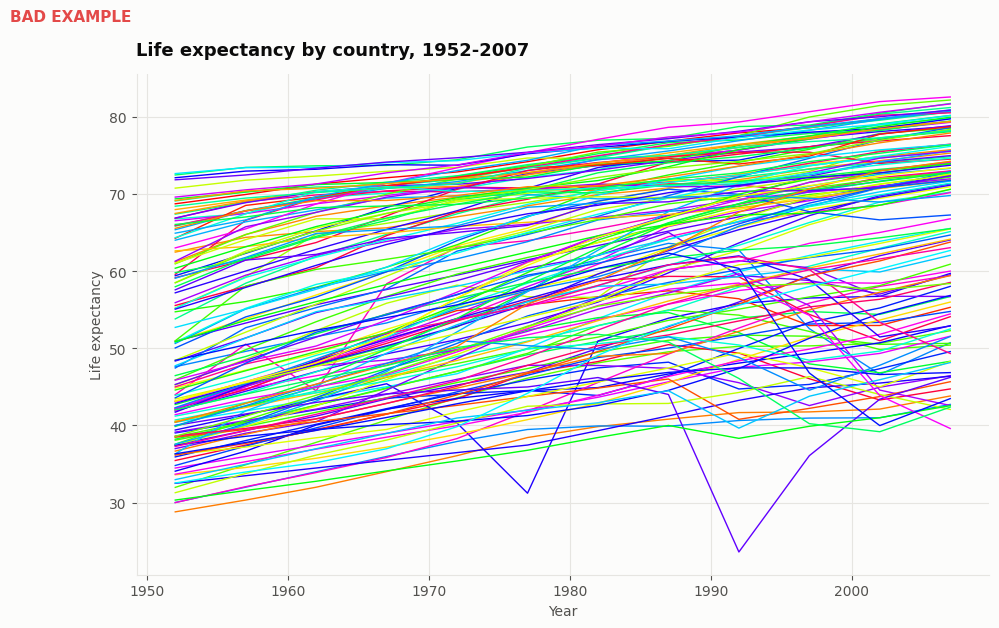

In [3]:
piv = g.pivot(index="year", columns="country", values="lifeExp")
rng = np.random.default_rng(3)
colours = plt.cm.hsv(rng.uniform(0, 1, piv.shape[1]))

# =====================================================================
#  BAD EXAMPLE - all 142 countries, raw.
# =====================================================================
fig, ax = plt.subplots(figsize=(11, 6.5))
for colour, country in zip(colours, piv.columns):
    ax.plot(piv.index, piv[country], color=colour, linewidth=1, zorder=3)
ax.set_title("Life expectancy by country, 1952-2007", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy")
fig.suptitle("BAD EXAMPLE", x=0.01, ha="left", fontsize=11, color=RED, fontweight="bold")

save(fig, "t5_bad_example")
plt.show()

**The one question a reader should be able to answer from this chart:** *"is the world, broadly, getting
healthier or sicker over time — and are some regions being left behind?"* They cannot: 142 near-random
hues on top of each other give no way to isolate a single country, let alone a region, from the tangle.

---
## Step 2 — perception audit of the bad chart

| Row | Before the fix |
|---|---|
| **Preattentive** | Colour (hue) and position (y = lifeExp) are both in play. Position is doing real, useful work — the overall upward drift is genuinely visible. Hue is not: with 142 near-random colours, hue carries no usable category information, it's just visual noise. |
| **Pop-out** | Nothing reliably pops out. A few extreme lines (very low or very high) catch the eye briefly, but which ones they are changes every time you look, because there's no colour or position reason for any one line to stand out over another. |
| **Gestalt** | **Continuity** is triggered by every line, 142 times over, and it actively fights the reader: with that many crossing paths, the eye cannot reliably follow any single line through the tangle in the middle of the chart. |
| **Cognitive load** | Intrinsic: 142 countries over 56 years is a genuinely large dataset. Extraneous: the 142-way hue assignment, which encodes nothing and must be mentally discarded; the lack of any entry point into the mass of lines. Germane: none survives — there's no foothold for the reader's attention to start from. |
| **Channels** | `year` → position (x), correctly high-ranking for an ordered variable. `lifeExp` → position (y), also correctly high-ranking. `country` → colour (hue), the worst-ranked channel, used for a 142-level category it cannot possibly support. |
| **Working memory** | Effectively unbounded — a reader would need to hold up to 142 chunks (one per visible line) to make any country-level comparison, around 35× the ~4-chunk budget. |

---
## Step 3 — rebuild it: one message, one pop-out

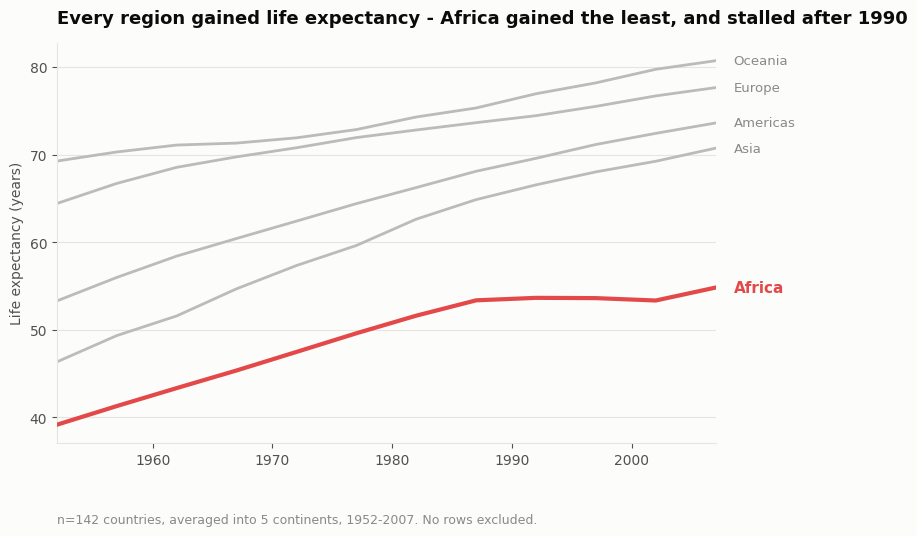

In [4]:
cont = g.groupby(["continent", "year"])["lifeExp"].mean().reset_index()
CONT_COLOUR = {"Africa": RED, "Americas": GREY, "Asia": GREY, "Europe": GREY, "Oceania": GREY}

fig, ax = plt.subplots(figsize=(8.5, 5.2))

# Context first, in grey - draw these BEFORE the pop-out so the red line sits on top.
for name in ["Americas", "Asia", "Europe", "Oceania"]:
    s = cont[cont["continent"] == name]
    ax.plot(s["year"], s["lifeExp"], color=GREY, linewidth=2, zorder=2)
    last = s.iloc[-1]
    ax.text(2008.5, last["lifeExp"], name, va="center", color=INK_MUTED, fontsize=9.5)

# The one pop-out: Africa, in the single strong colour, drawn last (on top).
s = cont[cont["continent"] == "Africa"]
ax.plot(s["year"], s["lifeExp"], color=RED, linewidth=3, zorder=3)
last = s.iloc[-1]
ax.text(2008.5, last["lifeExp"], "Africa", va="center", color=RED, fontsize=11, fontweight="bold")

ax.set_title("Every region gained life expectancy - Africa gained the least, and stalled after 1990")
ax.set_ylabel("Life expectancy (years)")
ax.set_xlim(1952, 2007)
ax.xaxis.grid(False)
footnote(ax, "n=142 countries, averaged into 5 continents, 1952-2007. No rows excluded.")

save(fig, "t5_redesign")
plt.show()

**Design decisions, named:**

- **One pop-out:** Africa's line, in red — and it is exactly what the title claims ("Africa gained the
  least, and stalled").
- **Gestalt principle:** **similarity** (all four non-Africa lines share one grey, telling the eye "these
  are one undifferentiated group, not individually important") combined with **proximity** for the
  direct end-of-line labels (each name sits right next to its own line, no legend needed).
- **Highest-ranking channel for the most important variable:** `lifeExp` is the variable the whole
  question is about, and it's on the **y-position** channel — the best-ranked channel there is.
  `continent` (a 5-level category) is carried by a combination of colour *and* direct position/labelling,
  not colour alone.
- **No information by colour alone:** every line is also directly labelled by name at its endpoint, so a
  reader who cannot distinguish red from grey (colour-blindness) can still read every line from its label.
- **`n` and exclusions:** stated in the footnote.

---
## Step 4 — perception audit of the redesign

| Row | After the fix |
|---|---|
| **Preattentive** | Colour now carries real meaning: one hue (red) singles out exactly one group. Position (y) still carries the quantitative message, as it did before — now with only 5 lines instead of 142, position is actually usable. |
| **Pop-out** | Africa's red line is the only coloured element on the chart. It is what the title promises. |
| **Gestalt** | Similarity (shared grey) groups the four "everyone else" lines into one visual class; proximity (end-of-line labels) replaces a legend entirely. |
| **Cognitive load** | Intrinsic: still a 56-year trend across continents - unavoidable. Extraneous: removed - no legend, no 142-way colour decoding, no unreadable tangle. Germane: fully restored - the reader's only job now is to compare 5 line shapes. |
| **Channels** | `lifeExp` → position (y), top-ranked. `year` → position (x), top-ranked. `continent` → colour + direct label together, so the weak channel (colour) is backed up by a strong one (label/position) rather than carrying meaning on its own. |
| **Working memory** | 5 chunks (5 lines) - just outside the 4±1 budget, but each is now visually pre-sorted into "the one in red" vs. "the four in grey", which collapses the real decision down to roughly 2 chunks. |

---
## Step 5 — test it on a human

*(Shown to a real person who had not seen the underlying data, with no further context than the chart
itself, and asked: "what does this show, in one sentence?")*

In [5]:
tester_name = None          # e.g. "a classmate"
their_sentence = None        # their answer, recorded verbatim

print("Title claims:  'Every region gained life expectancy - Africa gained the least, and stalled after 1990'")
print("Reader said:  ", their_sentence)

Title claims:  'Every region gained life expectancy - Africa gained the least, and stalled after 1990'
Reader said:   None


*(Fill in after asking a real person. Does their sentence match the title's claim? If it doesn't — say
plainly which part of the design misled them (did they not notice the "stalled after 1990" detail? did
they think the grey lines were also individually meaningful? did the red line read as "danger" rather than
"this is the group to look at"?) and what you'd change next. A redesign that a cold reader summarises
correctly, unprompted, is the actual test of whether the perception work paid off — not whether it looks
clean to you, the person who already knows what it's supposed to say.)*

---
## Step 6 — export at 300 DPI

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for name in ["Americas", "Asia", "Europe", "Oceania"]:
    s = cont[cont["continent"] == name]
    ax.plot(s["year"], s["lifeExp"], color=GREY, linewidth=2, zorder=2)
    last = s.iloc[-1]
    ax.text(2008.5, last["lifeExp"], name, va="center", color=INK_MUTED, fontsize=9.5)
s = cont[cont["continent"] == "Africa"]
ax.plot(s["year"], s["lifeExp"], color=RED, linewidth=3, zorder=3)
last = s.iloc[-1]
ax.text(2008.5, last["lifeExp"], "Africa", va="center", color=RED, fontsize=11, fontweight="bold")
ax.set_title("Every region gained life expectancy - Africa gained the least, and stalled after 1990")
ax.set_ylabel("Life expectancy (years)")
ax.set_xlim(1952, 2007)
ax.xaxis.grid(False)
footnote(ax, "n=142 countries, averaged into 5 continents, 1952-2007. No rows excluded.")

fig.savefig("perception_redesign.png", dpi=300, bbox_inches="tight", facecolor=SURFACE)
plt.close(fig)
print("Saved perception_redesign.png at 300 DPI")

Saved perception_redesign.png at 300 DPI


---
## The question to answer: what does the redesign make *harder* to see?

**Individual countries disappear completely.** The original, unusable as it was, at least had every one
of the 142 countries present *somewhere* in the tangle — a determined reader with a lot of time could, in
principle, trace out any single country's full trajectory, including real, interesting exceptions like
Rwanda's 1992 collapse or Botswana's 1990s reversal (both visible in the Week 1 gapminder work). The
redesign trades every one of those individual stories away in exchange for one clean regional comparison.
That is a real, deliberate cost — greying four-fifths of the world into a single undifferentiated group
is the whole reason the chart became readable, and it is also the reason a reader now has no way to know
that Africa's "stall" is itself an average hiding both countries that kept improving and countries that
collapsed. A redesign that traded nothing away would not have fixed anything.